# Preliminaries

## Dataset

In this set of exercises we will use the same dataset as from [week 3](week_3.ipynb). 


As before, we provide the data already curated in the following two files:

`RNA_expression_curated.csv`: [148 cell lines , 238 genes]

`drug_response_curated.csv`: [148 cell lines , YM155 drug]

The curated data can be read as `pandas` `DataFrame` in the following way:

In [144]:
import pandas as pd

gene_expression = pd.read_csv("./data/RNA_expression_curated.csv", sep=',', header=0, index_col=0)
drug_response = pd.read_csv("./data/drug_response_curated.csv", sep=',', header=0, index_col=0)

The goal of the exercises is to train support vector machine (SVM) and random forests classifiers on this dataset and explore and learn about their hyperparameters. 

## Tools

The `scikit-learn` library provides the required tools for support vector machines, as well as for random forest algorithms.

In [145]:
from sklearn import svm 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs, make_circles
from sklearn.metrics import classification_report

Before proceeding, look up the documentation of the imported functions and read about their basic functionality. Below, we list some important parameters of SVMs and random forests that can be tuned during training.

#### Support Vector Machines (SVM)

`C`: error term.

`kernel`: similarity function ('linear', 'poly', 'sigmoid' or 'rbf')

`gamma`: kernel coef. for 'rbf', 'poly' and 'sigmoid' kernels. It can be thought of as the ‘spread’ of the kernel and therefore the decision region.

`degree`: degree for the 'poly' kernel.

`coef0`: independt term in the 'poly' and 'sigmoid' kernels


#### Random Forests

`n_estimators`: number of trees in our random forest.

`max_depth`: maximum number of levels in each decision tree

`max_features`: maximum number of features to consider per split in an individual tree.

`min_sample_leaf`: minimum number of data points per leaf node

`min_samples_split`: minimum number of data points placed in a node before the node is split

`oob_score`: the out-of-bag (OOB) error is the average error for each observation calculated using predictions from the trees that do not contain that observation in their respective bootstrap sample. Set this parameter to true.

`bootstrap`: method for sampling data points (with or without replacement). Set this parameter to true.

`criterion`: function used to measure the quality of the split (e.g. 'entropy' or 'gini')

# Exercises

## Support vector machines

The  `make_blobs` and `make_circles` functions can be used to generate linearly and not linearly separable toy datasets. 

In [146]:
# data generation: linearly separable
X, Y = make_blobs(n_samples=200, centers=2, n_features=2, random_state=1234)
X = pd.DataFrame(X, columns=['x1', 'x2'])

# splitting data into training and test set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, random_state=333)

The following code illustrates how to train a linear SVM classifier and plot the data points, the separating hyperplane, the support vectors and the margins that pass through them (considering the training data)

/var/folders/ry/q7zdxv1d39xc3tffkwjx8r940000gn/T/ipykernel_13348/2438761054.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Paired')
/opt/anaconda3/envs/8dm50/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/8dm50/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


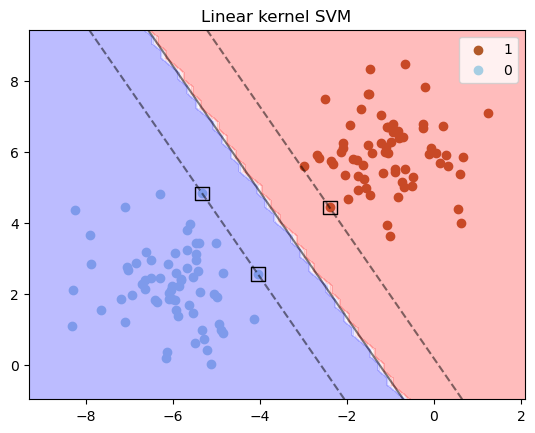

In [147]:
import numpy as np
import matplotlib.pyplot as plt

# build the model
model = svm.SVC(kernel='linear', random_state=33)
model.fit(X_train, Y_train)

# create plot
fig, ax = plt.subplots()

# get colors from qualitative colormap 'Paired'
cmap = plt.cm.get_cmap('Paired')

# plot data points
ax.scatter(X_train.iloc[Y_train == 1, 0], X_train.iloc[Y_train == 1, 1],
           c=[cmap(11)], label='1')
ax.scatter(X_train.iloc[Y_train == 0, 0], X_train.iloc[Y_train == 0, 1],
           c=[cmap(0)], label='0')
ax.legend(loc='best')

# plot the decision function
# create grid to evaluate model
x1_min, x1_max = X_train.iloc[:, 0].min() - 1, X_train.iloc[:, 0].max() + 1
x2_min, x2_max = X_train.iloc[:, 1].min() - 1, X_train.iloc[:, 1].max() + 1

XX, YY = np.meshgrid(np.arange(x1_min, x1_max, .2),
                     np.arange(x2_min, x2_max, .2))

xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model.decision_function(xy).reshape(XX.shape)

# plot decision boundary and margins
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])

# Establish the class for each point in the contour
Z = model.predict(xy).reshape(XX.shape)

# Visualization of the contour
ax.contourf(XX, YY, Z, cmap='bwr', alpha=0.3)

# plot support vectors, whose are responsible for building the margins
ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100,
           linewidth=1, facecolors='none', edgecolors='k', marker='s')

ax.axis([x1_min, x1_max, x2_min, x2_max])
plt.axis('tight')
plt.title('Linear kernel SVM')
plt.show()

Train a radial basis function (RBF) SVM classifier with `gamma=0.5` and plot the results in the same way.

In [148]:
# data generation: not linearly separable
X, Y = make_circles(n_samples=200, noise=0.05, random_state=1234)
X = pd.DataFrame(X, columns=['x1', 'x2'])

# splitting data into training and test set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, random_state=333)

/var/folders/ry/q7zdxv1d39xc3tffkwjx8r940000gn/T/ipykernel_13348/5143456.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Paired')
/opt/anaconda3/envs/8dm50/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/8dm50/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/8dm50/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


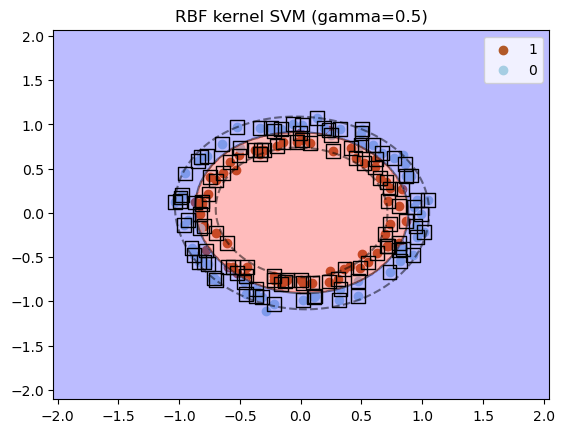

In [149]:
# train RBF SVM model
model_rbf = svm.SVC(kernel='rbf', gamma=0.5, random_state=33)
model_rbf.fit(X_train, Y_train)

# create plot
fig, ax = plt.subplots()

# get colors from qualitative colormap 'Paired'
cmap = plt.cm.get_cmap('Paired')

# plot data points
ax.scatter(X_train.iloc[Y_train == 1, 0], X_train.iloc[Y_train == 1, 1],
           c=[cmap(11)], label='1')
ax.scatter(X_train.iloc[Y_train == 0, 0], X_train.iloc[Y_train == 0, 1],
           c=[cmap(0)], label='0')
ax.legend(loc='best')

# create grid to evaluate model
x1_min, x1_max = X_train.iloc[:, 0].min() - 1, X_train.iloc[:, 0].max() + 1
x2_min, x2_max = X_train.iloc[:, 1].min() - 1, X_train.iloc[:, 1].max() + 1

XX, YY = np.meshgrid(np.arange(x1_min, x1_max, 0.02),
                     np.arange(x2_min, x2_max, 0.02))
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model_rbf.decision_function(xy).reshape(XX.shape)

# plot decision boundary and margins
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])

# visualization of decision regions
Z_pred = model_rbf.predict(xy).reshape(XX.shape)
ax.contourf(XX, YY, Z_pred, cmap='bwr', alpha=0.3)

# plot support vectors
ax.scatter(model_rbf.support_vectors_[:, 0], model_rbf.support_vectors_[:, 1],
           s=100, linewidth=1, facecolors='none', edgecolors='k', marker='s')

ax.axis([x1_min, x1_max, x2_min, x2_max])
plt.axis('tight')
plt.title('RBF kernel SVM (gamma=0.5)')
plt.show()


<p><font color='#dfcacaff'>When should a RBF kernel be used over a linear kernel? Motivate your answer.</font></p>

An RBF kernel should be used when the data cannot be separated well by a straight line or plane. It can capture complex, non-linear patterns by mapping the data into a higher-dimensional space where the classes become separable. A linear kernel is more appropriate when the relationship between the features and the target is approximately linear, or when the dataset has many features compared to the number of samples.

<p><font color='#dfcacaff'>Do we need to normalize the data before using a kernel function? Motivate your answer.
</font></p>

Yes, the data should be normalized before using a kernel function, because kernel methods like the RBF kernel rely on distance calculations between points. If the features are on very different scales, the feature with the largest range can dominate the distances and negatively affect the model’s performance. Normalizing the data ensures that all features contribute equally and that the kernel measures similarity correctly.

## Predicting drug response on cell lines from gene expression data with SVMs

Explore the hyper-parameter space of an SVM classifier with cross-validation for the Genomics of Drug Sensitivity in Cancer (GDSC) dataset. The`GridSearchCV` function can be used to specify a grid of parameter values with the `param_grid` parameter.

Calculate the precision of your predictions, and compare your calculations with the results of `classification_report`, which displays many classification metrics.


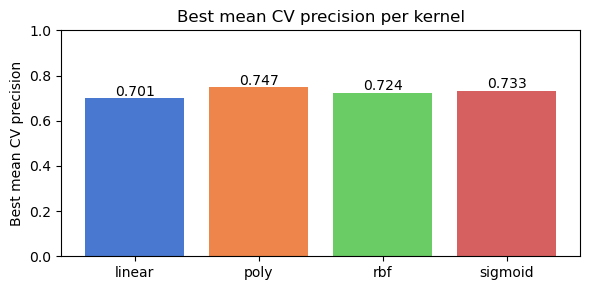

Best params: {'svc__C': 0.03162277660168379, 'svc__coef0': 1.0, 'svc__degree': 4, 'svc__gamma': 0.01, 'svc__kernel': 'poly'}
CV best precision: 0.7474969474969475
Test precision: 0.6190476190476191

Classification report:
               precision    recall  f1-score   support

           0       0.56      0.38      0.45        13
           1       0.62      0.76      0.68        17

    accuracy                           0.60        30
   macro avg       0.59      0.57      0.57        30
weighted avg       0.59      0.60      0.58        30



In [150]:
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, precision_score

# Prepare combined data (uses gene_expression and drug_response loaded earlier)
combined_df = drug_response.join(gene_expression.iloc[:, 0:], how='left')
combined_df = combined_df.reset_index()
combined_df = combined_df.rename(columns={combined_df.columns[0]: 'Cell line'})

# Features: all gene expression columns (assumes first columns are index and YM155)
X = combined_df.iloc[:, 2:]
y_cont = combined_df['YM155']

# Binary label via z-score across the curated set: sensitive (1) if z < 0, else resistant (0)
y = ((y_cont - y_cont.mean()) / y_cont.std() < 0).astype(int)

# Stratified split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Pipeline and expanded grid for SVM (linear, RBF, poly, sigmoid)
pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC())])

C_vals = list(np.logspace(-3, 3, 7))
gamma_rbf = list(np.logspace(-3, 1, 7))
C_small = list(np.logspace(-3, 3, 5))
gamma_small = list(np.logspace(-3, 0, 4))
coef0_small = [0.0] + list(np.logspace(-3, 0, 4))

param_grid = [
    {'svc__kernel': ['linear'], 'svc__C': C_vals},
    {'svc__kernel': ['rbf'], 'svc__C': C_vals, 'svc__gamma': gamma_rbf},
    {'svc__kernel': ['poly'],
     'svc__C': C_small,
     'svc__degree': [2, 3, 4],
     'svc__gamma': gamma_small,
     'svc__coef0': coef0_small},
    {'svc__kernel': ['sigmoid'],
     'svc__C': C_small,
     'svc__gamma': gamma_small,
     'svc__coef0': coef0_small},
]

# Use StratifiedKFold with 5 splits (shuffle for robustness). Set verbose and return_train_score for monitoring.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(pipe, param_grid, scoring='precision', cv=cv, n_jobs=-1)
gs.fit(X_train, y_train)

# build DataFrame from GridSearchCV results
cv = gs.cv_results_
df_cv = pd.DataFrame(cv)
params_df = pd.DataFrame(df_cv['params'].tolist())
df_cv = pd.concat([df_cv, params_df], axis=1)

# Best per kernel (max mean_test_score over parameter space)
best_per_kernel = df_cv.groupby('svc__kernel')['mean_test_score'].max().dropna()

plt.figure(figsize=(6,3))
bars = best_per_kernel.index.tolist()
scores = best_per_kernel.values
colors = sns.color_palette('muted', len(bars))
plt.bar(bars, scores, color=colors)
plt.ylabel('Best mean CV precision')
plt.title('Best mean CV precision per kernel')
plt.ylim(0,1)
for i,(b,s) in enumerate(zip(bars,scores)):
    plt.text(i, s+0.01, f"{s:.3f}", ha='center')
plt.tight_layout()
plt.show()

print('Best params:', gs.best_params_)
print('CV best precision:', gs.best_score_)

# Evaluate on test set
y_pred = gs.predict(X_test)
print('Test precision:', precision_score(y_test, y_pred))
print('\nClassification report:\n', classification_report(y_test, y_pred)) 

### Analyse van de SVM‑resultaten

- Kort samengevat: GridSearchCV selecteerde als beste combinatie een polynomial kernel (degree=4, C≈0.0316, gamma=0.01, coef0=1.0). De CV‑schatting (mean precision) is ~0.747, de gemeten precisie op de aparte testset is ~0.62.

- Waarom poly gekozen is: GridSearchCV kiest de enkele parametercombinatie met de hoogste mean CV‑score. De eerder getoonde "aggregated" plot toont gemiddelden over andere hyperparameters en kan daardoor misleidend zijn; één specifieke poly‑combinatie kan nét beter scoren dan de beste linear‑combinatie ondanks dat de gemiddelde linear‑curve hoger lijkt.

- Waarom de testscore lager is dan de CV‑score: mogelijk overfitting (poly is complex), hoge variantie door klein testset (30 samples), of toevallige afwijking tussen splits. Controleer std_test_score en de top‑rangen in gs.cv_results_ om te zien of het verschil significant is.

- Concrete controles / vervolgstappen:
  1) Print de top‑10 CV‑resultaten (pd.DataFrame(gs.cv_results_).sort_values('mean_test_score',ascending=False).head(10)) om exact te zien welke combinaties hoog scoorden.
  2) Voer repeated stratified CV of nested CV uit (bv. StratifiedKFold met meerdere random shuffles of nested CV) voor robuustere selectie.
  3) Vergelijk simpel vs complex model: als verschil in mean_test_score klein is en std groot, kies dan het eenvoudigere model (linear) voor betere generalisatie.
  4) Controleer klasse‑verdeling en overweeg andere scoringsmaten (precision_macro, recall, f1) of class_weight='balanced' als klassen ongelijk zijn.
  5) Visualiseer per‑combinatie resultaten (heatmaps / top‑rijen) zoals in de notebook zodat de winnende cel duidelijk zichtbaar is.

- Conclusie: de gekozen poly‑combinatie is technisch correct als dat de hoogste mean CV‑precision opleverde, maar de lagere testprecision en mogelijke ruis suggereren dat extra validatie (repeated/nested CV of meerdere random splits) nodig is voordat je confident kiest dat poly echt beter generaliseert dan linear.



## Random forests

Follow the same steps as for SVM. Compare the two algorithms and report which one has better performance.

The random forests classifiers allows to perform feature selection. Evaluate the importance of features extracting the top 50 informative features. A bar plot (`plt.bar()`) can be a useful tool to visualize this. 




## Biomedical applications

Driven by technological advances, there has recently been a dramatic increase in availability of biomedical data. Machine learning approaches are well suited to take advantage of this data and have been widely applied to many areas of biology. 

Example of these applications are genome annotation, biomarker identification, systems biology, genome data analysis, protein  function  prediction, protein  structure prediction, protein localization prediction, identification of protein interactions and drug discovery.

SVM and RF methods are among the most popular machine learning methods applied in bioinformatics or computational biology.

Perform a literature search and find a biomedical study in which SVM or RF is applied to obtain certain insights. <p><font color='#dfcacaff'>Explain the motivation behind using that specific algorithm in the study.
</font></p>

We choose: https://www.nature.com/articles/s41591-025-03890-6

the paper analyzed plasma proteomic data from patients with amyotrophic lateral sclerosis (ALS) to identify biomarkers and build a diagnostic model. They tested ten different machine learning algorithms and found that the Random Forest method performed best in distinguishing ALS cases from control individuals. Random Forest is particularly suitable for this kind of data because proteomic datasets contain thousands of interrelated variables, and the method can handle high dimensional and nonlinear data effectively. It also reduces overfitting through ensemble learning and provides feature importance scores, which help identify the proteins that contribute most to disease classification. These characteristics made Random Forest an excellent choice for discovering a molecular signature of ALS and developing a robust, interpretable diagnostic model.